# Airline NLP Sentiment Analysis

## Introduction

Natural Language Processing (NLP) is presently among the hottest scientific fields with an enormous growth rate of the relevant research. Sentiment analysis is a popular NLP problem that aims at the automatic identification of the polarity in user reviews, tweets, blog posts, comments, forum discussions and so on.

In the vast majority of cases, sentiment analysis is treated as a text classification problem. If the involved text polarity is binary (i.e., positive or negative, good or bad), then binary text classification models are trained by utilizing two class labels. In case the polarity falls into a closed score range (e.g., 1–5, 1–10, etc.), then each individual score is treated as a separate class label and multi-class classification approaches are applied.

Treating sentiment analysis as a classification problem allows companies to build automated media monitoring systems that track customer satisfaction and crisis events in real time.

In this project we will explore various classifiers on NLP sentiment analysis. The purpose is to measure their performance on a dataset that derives from X (formerly Twitter) and contains user opinions about a US Airliner.

### Classifiers
The classifiers to be studied are:
* $C_1$: Logistic Regression
* $C_2$: Support Vector Machines (Linear kernel)
* $C_3$: Random Forests
* $C_4$: Feed-forward Neural Network

### Dataset

The classification performance of the abovementioned models will be studied on the `Twitter_US_Airline_Sentiment.csv` dataset ([see more details here](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)).

## Experiments

We use TF-IDF for text vectorization. In a production environment handling streaming social media, the size of the feature space directly impacts both memory consumption and model latency. To evaluate this trade-off, we will test three different vocabulary constraints for the `TfidfVectorizer`:

1. Baseline Constraint: Words appearing in at least 5 documents.
2. Moderate Dimensionality: A fixed vocabulary of the 2,500 most frequent terms.
3. Aggressive Dimensionality Reduction: A severely restricted vocabulary of 500 terms.

The classifiers will be evaluated by using 5-fold cross validation. We will make sure that no information will be leaked from the training set to the test set. The values of the four following metrics will be measured:

* $M_1$: Accuracy
* $M_2$: F1-score
* $M_3$: Fit time

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, accuracy_score, f1_score
import matplotlib.pyplot as plt

Let's load the dataset and see what we're dealing with.

In [2]:
df = pd.read_csv('Twitter_US_Airline_Sentiment.csv')
df

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


We now split the dataset into input and target variables.

In [3]:
X = df['text']
Y = df['airline_sentiment']

Finally, we make a couple of collections for the scorers and classifiers we're going to be using during cross-validation. The parameters were chosen using `GridSearchCV`.

In [4]:
scorers = {
    'accuracy_score': make_scorer(accuracy_score),
    'f1_score': make_scorer(f1_score, average='weighted')
    # fit time already exists as an output of the method
}

classifiers = [
    LogisticRegression(C=1, solver='liblinear', random_state=1),
    LinearSVC(C=1, random_state=1),
    RandomForestClassifier(n_estimators=200, min_samples_split=5,  n_jobs=-1, random_state=1),
    MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, solver='adam', random_state=1)
]


The following blocks execute 5-fold cross-validation. Crucially, by embedding the `TfidfVectorizer` inside a scikit-learn `Pipeline`, we guarantee that the TF-IDF weights are calculated exclusively on the training folds at each step. This strictly prevents data leakage from the test set.

In [5]:
# Case 1: Contain words that appear in at least 5 documents
vectorizer1 = TfidfVectorizer(min_df=5)

cv_results_v1 = []
for classifier in classifiers:
    pipe1 = Pipeline([('vectorizer', vectorizer1), ('classifier', classifier)])
    scores = cross_validate(pipe1, X, Y, cv=5, scoring=scorers, return_train_score=False, n_jobs=-1)
    cv_results_v1.append({
            'Classifier': classifier.__class__.__name__,
            'Accuracy': scores['test_accuracy_score'].mean(),
            'F1-Score': scores['test_f1_score'].mean(),
            'Fit Time': scores['fit_time'].mean(),
        })
results_v1_df = pd.DataFrame(cv_results_v1).set_index("Classifier")
results_v1_df

,Accuracy,F1-Score,Fit Time
Classifier,,,
LogisticRegression,0.757104,0.732699,0.183194
LinearSVC,0.757582,0.748868,0.152718
RandomForestClassifier,0.708265,0.675152,4.249284
MLPClassifier,0.709631,0.709324,95.354693


In [6]:
# Case 2: Contain 2500 words
vectorizer2 = TfidfVectorizer(max_features=2500)

cv_results_v2 = []
for classifier in classifiers:
    pipe2 = Pipeline([('vectorizer', vectorizer2), ('classifier', classifier)])
    scores = cross_validate(pipe2, X, Y, cv=5, scoring=scorers, return_train_score=False, n_jobs=-1)
    cv_results_v2.append({
            'Classifier': classifier.__class__.__name__,
            'Accuracy': scores['test_accuracy_score'].mean(),
            'F1-Score': scores['test_f1_score'].mean(),
            'Fit Time': scores['fit_time'].mean(),
        })
results_v2_df = pd.DataFrame(cv_results_v2).set_index("Classifier")
results_v2_df

,Accuracy,F1-Score,Fit Time
Classifier,,,
LogisticRegression,0.758265,0.734282,0.199005
LinearSVC,0.760997,0.751703,0.158272
RandomForestClassifier,0.706899,0.672644,4.303674
MLPClassifier,0.709904,0.707279,94.272266


In [7]:
# Case 3: Contain 500 words
vectorizer3 = TfidfVectorizer(max_features=500)

cv_results_v3 = []
for classifier in classifiers:
    pipe3 = Pipeline([('vectorizer', vectorizer3), ('classifier', classifier)])
    scores = cross_validate(pipe3, X, Y, cv=5, scoring=scorers, return_train_score=False, n_jobs=-1)
    cv_results_v3.append({
            'Classifier': classifier.__class__.__name__,
            'Accuracy': scores['test_accuracy_score'].mean(),
            'F1-Score': scores['test_f1_score'].mean(),
            'Fit Time': scores['fit_time'].mean(),
        })
results_v3_df = pd.DataFrame(cv_results_v3).set_index("Classifier")
results_v3_df

,Accuracy,F1-Score,Fit Time
Classifier,,,
LogisticRegression,0.742555,0.719212,0.187068
LinearSVC,0.746585,0.732470,0.170372
RandomForestClassifier,0.695902,0.668760,4.390697
MLPClassifier,0.716667,0.709162,8.822587


We visualize the results of comparing the different classifiers across different vectorizer cases.

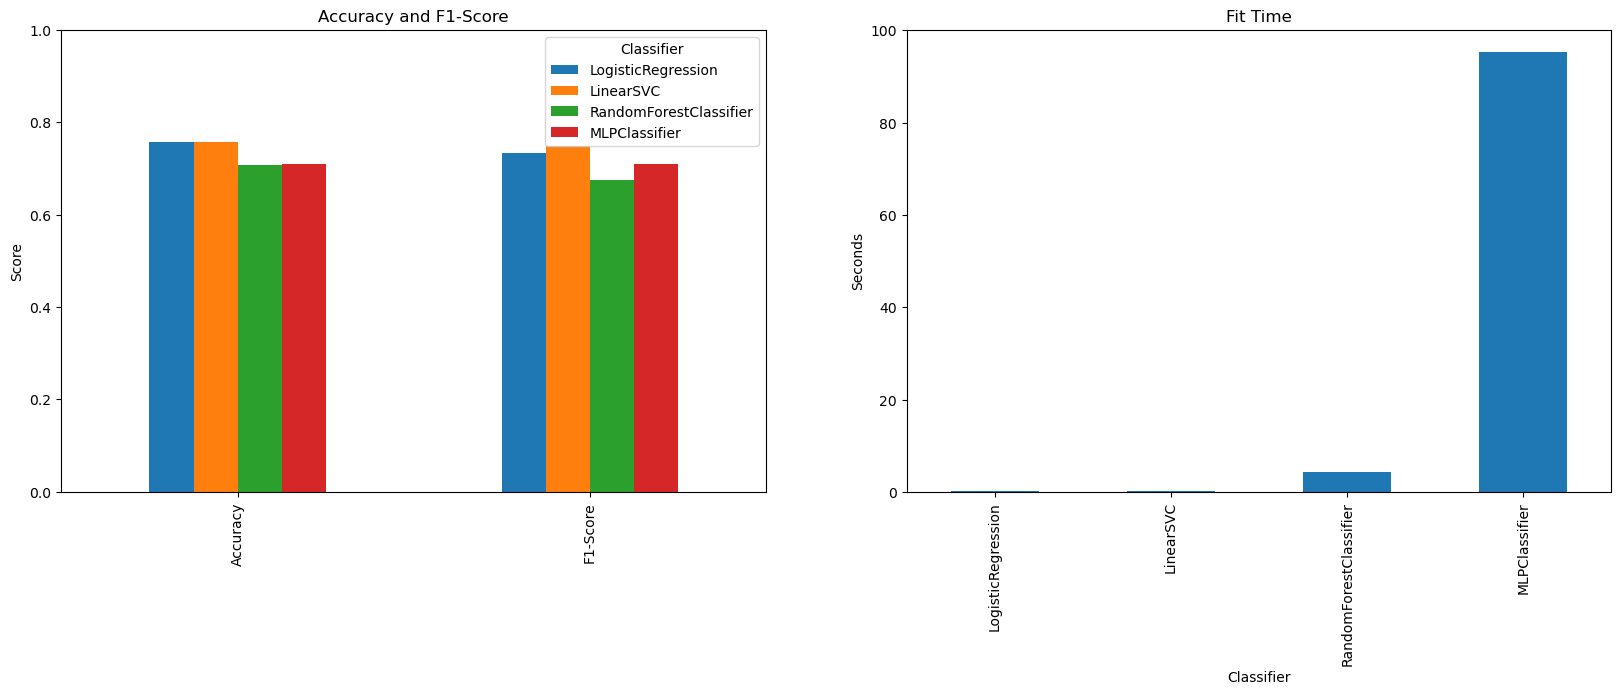

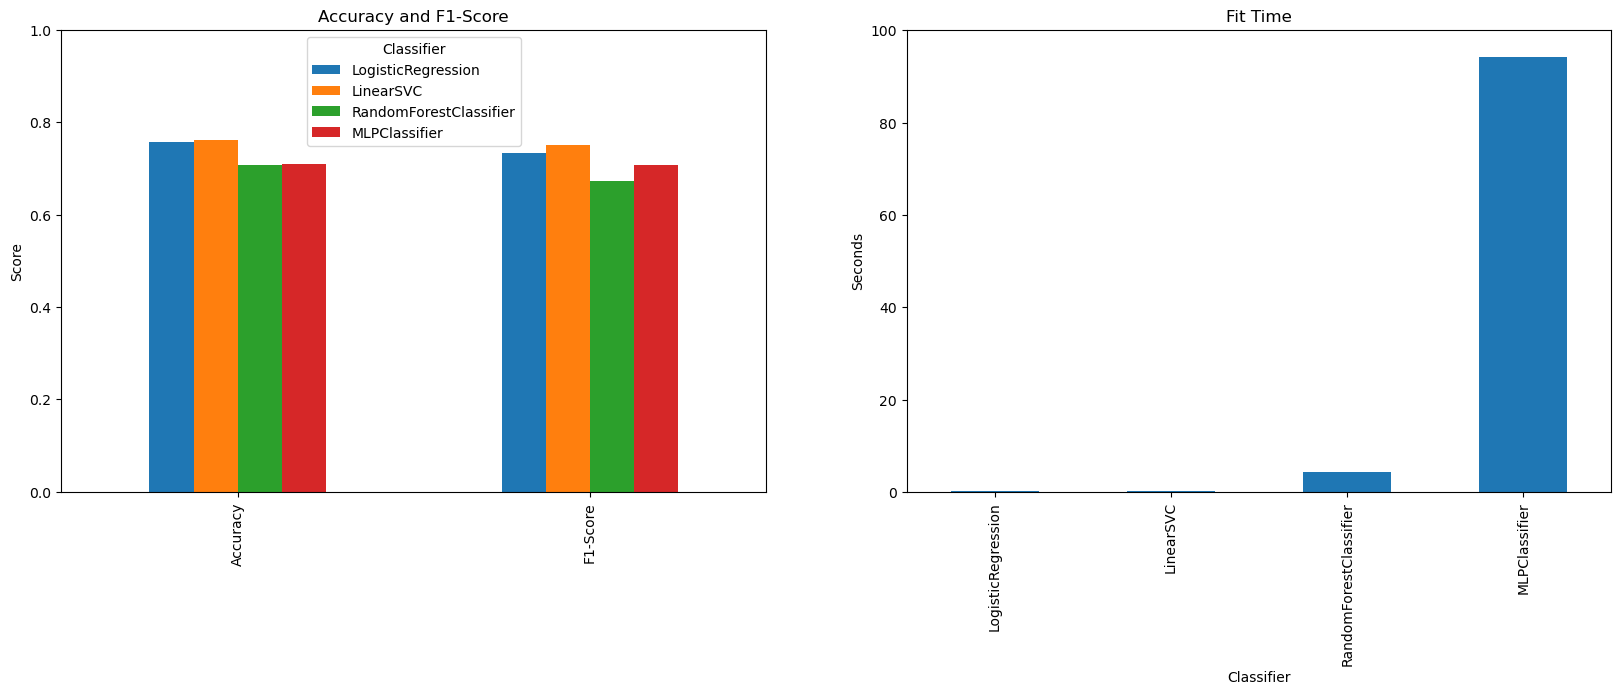

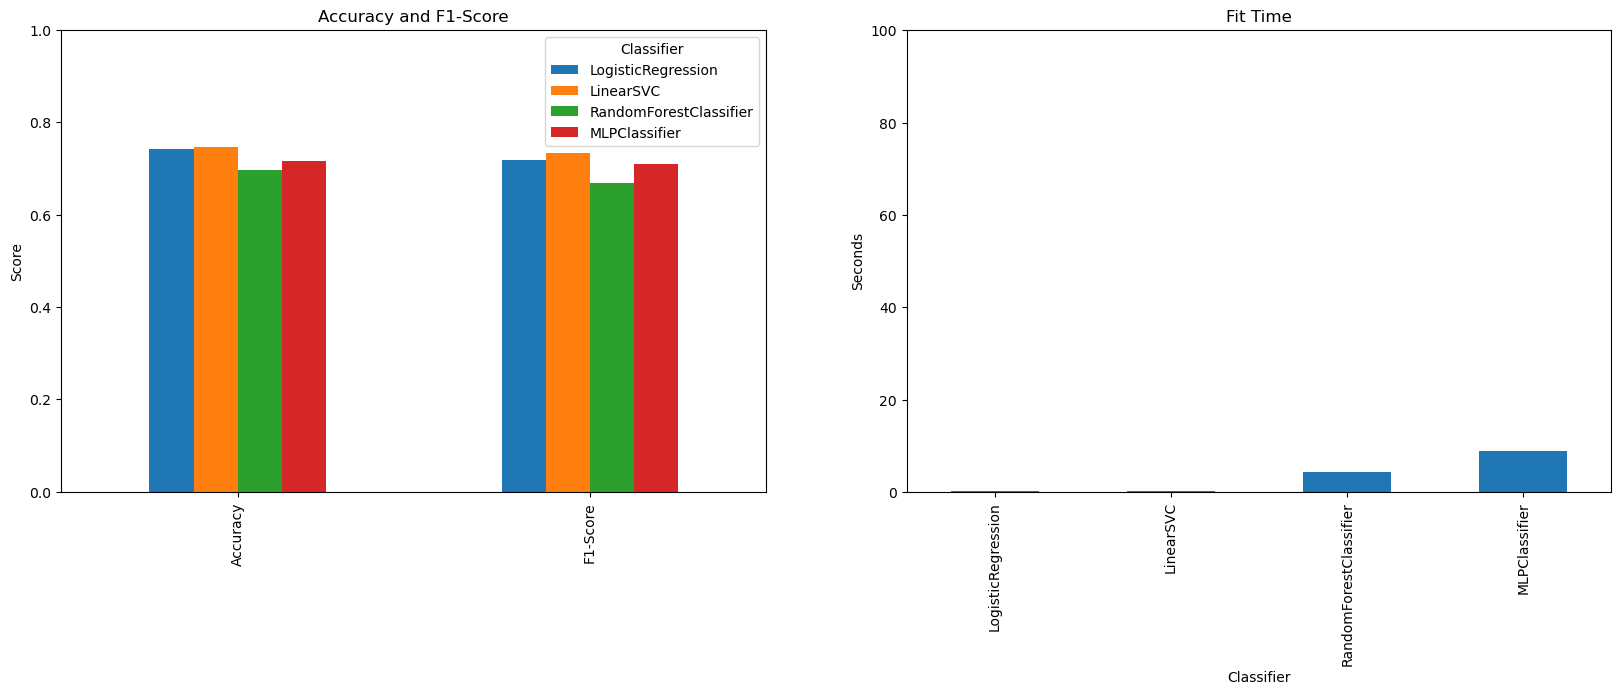

In [8]:
max_fit_time = max(result['Fit Time'].max() for result in [results_v1_df, results_v2_df, results_v3_df])

for result in [results_v1_df, results_v2_df, results_v3_df]:
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    result[['Accuracy', 'F1-Score']].T.plot(kind='bar', ax=ax[0])
    ax[0].set_ylim(0, 1)
    ax[0].set_ylabel('Score')
    ax[0].set_title('Accuracy and F1-Score')

    result['Fit Time'].plot(kind='bar', ax=ax[1])
    ax[1].set_ylim(0, max_fit_time * 1.05)
    ax[1].set_ylabel('Seconds')
    ax[1].set_title('Fit Time')
    plt.show()


Next, we evaluate the effect of standardizing the TF-IDF features. Because `TfidfVectorizer` outputs a sparse matrix, we use `StandardScaler` to prevent dense matrix memory overflow. The goal is to observe if forcing unit variance improves convergence for complex models or if it disrupts the inherent term-weighting of TF-IDF.

In [14]:
from sklearn.preprocessing import StandardScaler
vectorizer4 = TfidfVectorizer(max_features=2500)

cv_results_v4 = []
for classifier in classifiers:
    pipe4 = Pipeline([('vectorizer', vectorizer4), ('scaler', StandardScaler(with_mean=False)), ('classifier', classifier)])
    scores = cross_validate(pipe4, X, Y, cv=5, scoring=scorers, return_train_score=False, n_jobs=-1)
    cv_results_v4.append({
            'Classifier': classifier.__class__.__name__,
            'Accuracy': scores['test_accuracy_score'].mean(),
            'F1-Score': scores['test_f1_score'].mean(),
            'Fit Time': scores['fit_time'].mean(),
        })
results_v4_df = pd.DataFrame(cv_results_v4).set_index("Classifier")
results_v4_df

,Accuracy,F1-Score,Fit Time
Classifier,,,
LogisticRegression,0.708197,0.705795,0.410039
LinearSVC,0.698361,0.699397,0.778875
RandomForestClassifier,0.706967,0.672686,3.424242
MLPClassifier,0.736817,0.731284,39.721412


Finally, we explore the impact of explicit text pre-processing. Social media text is highly unstructured. We apply a custom regex-based preprocessor to strip HTML tags, extract and preserve emoticons (which carry high sentiment value), remove non-alphanumeric noise and strip standard English stop-words via `NLTK`. We will test this processed corpus against our baseline models to measure the trade-off between dimensionality reduction and the potential loss of sentiment-bearing context.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = stopwords.words('english')
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' ' .join(emoticons).replace('-', ''))
    ret_text = ""
    for word in text.split():
        if word not in stop:
            ret_text += word + " "
    ret_text = ret_text.strip()
    if len(ret_text) == 0:
        ret_text = "Invalid"
    return ret_text
X_processed = X.apply(preprocessor)

vectorizer5 = TfidfVectorizer(max_features=2500)
cv_results_v5 = []
for classifier in classifiers:
    pipe5 = Pipeline([('vectorizer', vectorizer5), ('classifier', classifier)])
    scores = cross_validate(pipe5, X_processed, Y, cv=5, scoring=scorers, return_train_score=False, n_jobs=-1)
    cv_results_v5.append({
            'Classifier': classifier.__class__.__name__,
            'Accuracy': scores['test_accuracy_score'].mean(),
            'F1-Score': scores['test_f1_score'].mean(),
            'Fit Time': scores['fit_time'].mean(),
        })
results_v5_df = pd.DataFrame(cv_results_v5).set_index("Classifier")
results_v5_df

## Discussion

Analyzing the results across the different preprocessing and vectorization constraints reveals several key insignts:

1. Linear Models Provide the Optimal Trade-off: LinearSVC and LogisticRegression consistently outperformed complex models. While RandomForest and MLPClassifier provide moderately good performance, their massive Fit Time latency makes them highly impractical for real-time social media processing. SVM yields the highest accuracy at a fraction of the computational cost.

2. Scaling Disrupts TF-IDF Weighting: Standardizing the features improved both accuracy and fit time for the MLPClassifier (which relies on gradient descent), but it degraded the performance of our best linear models. Since the baseline SVM still outperforms the scaled MLP, standardization should be omitted from the production pipeline.

3. Aggressive Cleaning Removes Signal, Not Just Noise: Applying the NLTK stop-word removal and regex cleaning successfully reduced fit time, but it notably dropped overall accuracy. This indicates that in short-form Twitter text, "stop-words" and raw punctuation often carry crucial semantic context for sentiment. The slight computational gain is not worth the loss in predictive power.

Final Recommendation: For a production deployment, an unscaled LinearSVC model utilizing a moderately constrained TF-IDF vocabulary (without aggressive stop-word removal) provides the most efficient solution for this dataset.